In [20]:
# Differentiable non-uniform ADC + demo plots for different return modes, STE, and temperatures.
# Uses matplotlib (no seaborn, no explicit colors), one chart per figure as requested.

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


class DifferentiableADC(nn.Module):
    """
    Differentiable non-uniform ADC based on measured transition levels.

    Inputs/outputs are fp32. Output is either:
      - normalized code in [0,1] (default),
      - integer code (returned as float, for convenience),
      - or a hard (discretized) version with STE.

    Construction:
      - Use `from_transition_table(...)` to build from measured (vin, code) pairs.
      - Or pass `edges` (K-1 transitions) directly, and optional `levels` (K code levels).

    Notation:
      - edges: tensor [K-1], strictly increasing transition voltages (in same units as x)
      - levels: tensor [K], output level per bin; default is normalized codes c/(K-1)

    Smoothing:
      - Uses a soft staircase via differences of sigmoids:
           p_i(x) = σ((x - e_{i-1})/τ) - σ((x - e_i)/τ), with e_{-1}=-∞, e_{K}=+∞
        implemented as concatenated [1-σ(x-e_0), σ(x-e_0)-σ(x-e_1), ..., σ(x-e_{K-2})].
      - τ is set relative to the median LSB unless specified.
    """

    def __init__(
        self,
        edges,
        levels=None,
        temperature=None,
        trainable_edges=False,
        enforce_monotonic=True,
    ):
        super().__init__()
        edges = torch.as_tensor(edges, dtype=torch.float32)
        assert edges.ndim == 1 and edges.numel() >= 1, "edges must be 1D, length >=1"

        K = edges.numel() + 1
        if levels is None:
            levels = torch.arange(K, dtype=torch.float32) / (K - 1)
        else:
            levels = torch.as_tensor(levels, dtype=torch.float32)
            assert levels.ndim == 1 and levels.numel() == K, (
                "levels must be length K=len(edges)+1"
            )

        if temperature is None:
            diffs = torch.diff(edges)
            lsb = torch.median(diffs) if diffs.numel() > 0 else torch.tensor(1.0)
            temperature = float(lsb.item() * 0.125)

        self.K = K
        self.enforce_monotonic = enforce_monotonic
        self.register_buffer("levels", levels)
        self.tau = nn.Parameter(
            torch.tensor(float(temperature), dtype=torch.float32), requires_grad=False
        )

        if trainable_edges:
            self.raw_edges = nn.Parameter(edges.clone())
            self.register_buffer("fixed_edges", None)
        else:
            self.register_buffer("fixed_edges", edges.clone())
            self.raw_edges = None

    @staticmethod
    def _monotone_edges(raw):
        if raw.numel() == 1:
            return raw
        d = F.softplus(raw[1:] - raw[:-1])
        e0 = raw[0:1]
        return torch.cat([e0, e0 + torch.cumsum(d, dim=0)], dim=0)

    def _get_edges(self):
        if self.raw_edges is None:
            return self.fixed_edges
        if self.enforce_monotonic:
            return self._monotone_edges(self.raw_edges)
        return self.raw_edges

    def forward(self, x, return_mode="normalized", hard=False):
        x = x.to(dtype=torch.float32)
        edges = self._get_edges()  # [K-1]
        tau = torch.clamp(self.tau, min=1e-6)

        s = torch.sigmoid((x.unsqueeze(-1) - edges) / tau)  # [..., K-1]

        left = 1.0 - s[..., :1]  # p_0
        mid = s[..., :-1] - s[..., 1:]  # p_1 .. p_{K-2}
        right = s[..., -1:]  # p_{K-1}
        p = torch.cat([left, mid, right], dim=-1)  # [..., K]; sums ~1

        y_soft = torch.sum(p * self.levels, dim=-1)  # [...]

        if return_mode == "int":
            y_soft_codes = y_soft * (self.K - 1)
            if hard:
                y_hard_codes = torch.round(y_soft_codes)
                return y_hard_codes + (y_soft_codes - y_soft_codes.detach())
            return y_soft_codes

        if hard:
            y_hard = torch.round(y_soft * (self.K - 1)) / (self.K - 1)
            return y_hard + (y_soft - y_soft.detach())
        return y_soft

    @classmethod
    def from_transition_table(
        cls,
        vin,
        code,
        *,
        code_is_float=True,
        nbits=None,
        temperature=None,
        trainable_edges=False,
        enforce_monotonic=True,
    ):
        vin = torch.as_tensor(vin, dtype=torch.float32).flatten()
        code = torch.as_tensor(code)

        if code_is_float:
            code = code.to(torch.float32).flatten()
        else:
            code = code.to(torch.int64).flatten()

        assert vin.numel() == code.numel() and vin.numel() >= 1, (
            "vin and code must align and be non-empty"
        )

        if code_is_float:
            unique = torch.unique(code).sort().values
            if unique.numel() < 1:
                raise ValueError("Transition code column has no values")
            steps = torch.diff(unique)
            step = steps.median().item() if steps.numel() > 0 else None
            if nbits is None:
                if step is None or step <= 0:
                    raise ValueError("Provide nbits (cannot infer from code floats).")
                K = int(round(1.0 / step) + 1)
            else:
                K = 1 << int(nbits)
            k = torch.round(code * (K - 1)).to(torch.int64)
        else:
            k = code.to(torch.int64)
            K = int(k.max().item()) + 1

        idx = torch.argsort(k)
        k_sorted = k[idx]
        vin_sorted = vin[idx]
        edges = torch.empty(K - 1, dtype=torch.float32)
        for kk in range(1, K):
            sel = k_sorted == kk
            if not torch.any(sel):
                raise ValueError(
                    f"Missing transition for code {kk} (need contiguous 1..K-1)."
                )
            edges[kk - 1] = vin_sorted[sel].mean()

        return cls(
            edges=edges,
            levels=torch.arange(K, dtype=torch.float32) / (K - 1),
            temperature=temperature,
            trainable_edges=trainable_edges,
            enforce_monotonic=enforce_monotonic,
        )

K (levels): 8
edges: tensor([-1.0000, -0.8639, -0.6151, -0.2929,  0.0887,  0.5215,  1.0000])
codes_transition: tensor([1, 2, 3, 4, 5, 6, 7])
Default tau: 0.009999999776482582
Monotonicity violations in soft output: False


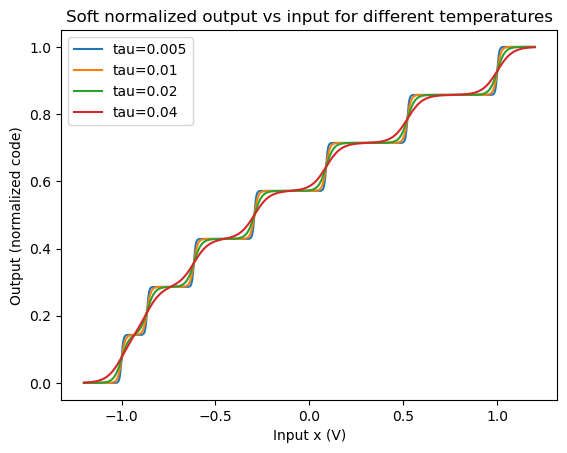

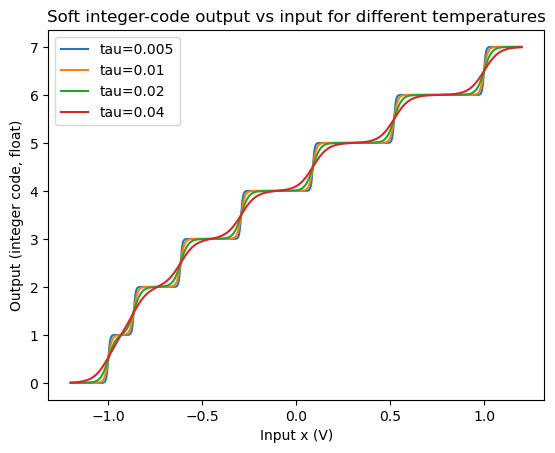

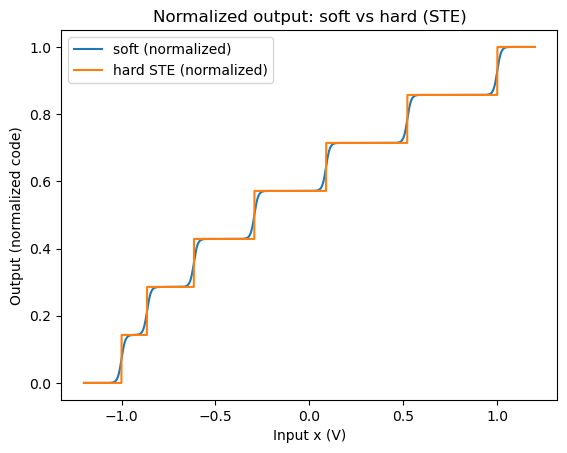

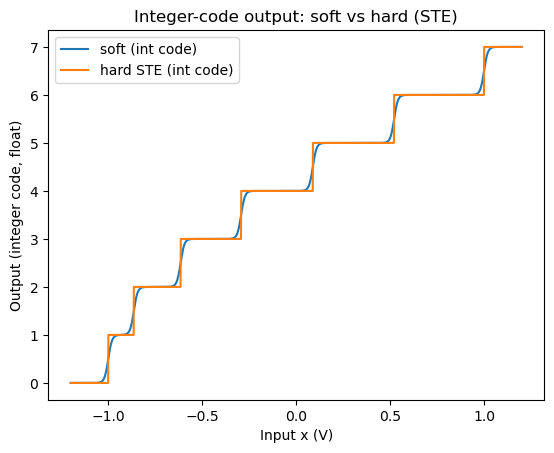

In [26]:
# --------------------------
# Build a sample non-uniform ADC from a transition table (synthetic demo)
# --------------------------
torch.manual_seed(0)

K = 8  # 5-bit for visually clear plots
u = torch.linspace(0, 1, K - 1)
# Non-uniform edges: compress near low end, expand near high end
edges = -1.0 + 2.0 * (u**1.5)
codes_transition = torch.arange(1, K, dtype=torch.int64)  # 1..K-1

adc = DifferentiableADC.from_transition_table(
    vin=edges,
    code=codes_transition,
    code_is_float=False,
    temperature=0.01,
    trainable_edges=False,
)

# Sanity checks
x_test = torch.linspace(-1.2, 1.2, 2000)
y_soft = adc(x_test, return_mode="normalized", hard=False)
# Monotonicity check (soft should be non-decreasing)
monotonic_violations = (torch.diff(y_soft) < -1e-6).any().item()

print("K (levels):", adc.K)
print("edges:", edges)
print("codes_transition:", codes_transition)
print("Default tau:", float(adc.tau.item()))
print("Monotonicity violations in soft output:", monotonic_violations)

# --------------------------
# Plots
# --------------------------

# 1) Soft (normalized) output for multiple temperatures
tau0 = float(adc.tau.item())
taus = [tau0 * 0.5, tau0, tau0 * 2.0, tau0 * 4.0]

plt.figure()
for t in taus:
    adc.tau.data = torch.tensor(t, dtype=torch.float32)
    y = adc(x_test, return_mode="normalized", hard=False).detach()
    plt.plot(x_test.numpy(), y.numpy(), label=f"tau={t:.4g}")
plt.xlabel("Input x (V)")
plt.ylabel("Output (normalized code)")
plt.title("Soft normalized output vs input for different temperatures")
plt.legend()
plt.show()

# 2) Soft (integer code) output for multiple temperatures
plt.figure()
for t in taus:
    adc.tau.data = torch.tensor(t, dtype=torch.float32)
    y = adc(x_test, return_mode="int", hard=False).detach()
    plt.plot(x_test.numpy(), y.numpy(), label=f"tau={t:.4g}")
plt.xlabel("Input x (V)")
plt.ylabel("Output (integer code, float)")
plt.title("Soft integer-code output vs input for different temperatures")
plt.legend()
plt.show()

# 3) Hard (STE) normalized output at a representative temperature
adc.tau.data = torch.tensor(tau0, dtype=torch.float32)
y_soft_rep = adc(x_test, return_mode="normalized", hard=False).detach()
y_hard_rep = adc(x_test, return_mode="normalized", hard=True).detach()

plt.figure()
plt.plot(x_test.numpy(), y_soft_rep.numpy(), label="soft (normalized)")
plt.plot(x_test.numpy(), y_hard_rep.numpy(), label="hard STE (normalized)")
plt.xlabel("Input x (V)")
plt.ylabel("Output (normalized code)")
plt.title("Normalized output: soft vs hard (STE)")
plt.legend()
plt.show()

# 4) Hard (STE) integer code at a representative temperature
y_soft_int = adc(x_test, return_mode="int", hard=False).detach()
y_hard_int = adc(x_test, return_mode="int", hard=True).detach()

plt.figure()
plt.plot(x_test.numpy(), y_soft_int.numpy(), label="soft (int code)")
plt.plot(x_test.numpy(), y_hard_int.numpy(), label="hard STE (int code)")
plt.xlabel("Input x (V)")
plt.ylabel("Output (integer code, float)")
plt.title("Integer-code output: soft vs hard (STE)")
plt.legend()
plt.show()